In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [2]:
BASE_PATH = Path("data/beto_carrero_world/")

In [3]:
def load_data(file_path):
  files = sorted(list(file_path.glob("**/*.csv")))
  
  print(f"Found {len(files)} CSV files in {file_path}")
  
  if not files:
    print("No CSV files found in the specified directory.")
    return None
  
  dfs_list = []
  
  for file in files:
    year = file.parent.name
    month = file.stem
    
    try:
      temp_df = pd.read_csv(file)
      temp_df["year_file"] = year
      temp_df["month_file"] = month
      
      dfs_list.append(temp_df)
      print(f"Loaded {year}/{month} successfully. {len(temp_df)} records")
    except Exception as e:
      print(f"Error loading {year}/{month}: {e}")
  
  final_df = pd.concat(dfs_list, ignore_index=True)
  
  if 'last_updated_api' in final_df.columns:
    final_df['last_updated_api'] = pd.to_datetime(final_df['last_updated_api'])
    
  return final_df
 
 

In [4]:
df = load_data(BASE_PATH)

Found 39 CSV files in data\beto_carrero_world
Loaded 2023/01 successfully. 42679 records
Loaded 2023/02 successfully. 39324 records
Loaded 2023/03 successfully. 24915 records
Loaded 2023/04 successfully. 48421 records
Loaded 2023/05 successfully. 45567 records
Loaded 2023/06 successfully. 44952 records
Loaded 2023/07 successfully. 90931 records
Loaded 2023/08 successfully. 42253 records
Loaded 2023/09 successfully. 52548 records
Loaded 2023/10 successfully. 87507 records
Loaded 2023/11 successfully. 81356 records
Loaded 2023/12 successfully. 81629 records
Loaded 2024/01 successfully. 81877 records
Loaded 2024/02 successfully. 82650 records
Loaded 2024/03 successfully. 47189 records
Loaded 2024/04 successfully. 62322 records
Loaded 2024/05 successfully. 52470 records
Loaded 2024/06 successfully. 49870 records
Loaded 2024/07 successfully. 95141 records
Loaded 2024/08 successfully. 89442 records
Loaded 2024/09 successfully. 41403 records
Loaded 2024/10 successfully. 42465 records
Loaded 2

In [5]:
# Criar uma tabela de referência de tudo que você já tem no DF principal
referencia_rides = df[['id', 'name']].drop_duplicates().sort_values(by='name')

print("--- ATRAÇÕES ATUALMENTE NO DATAFRAME ---")
print(referencia_rides)

# Verificar se os "problemáticos" aparecem com outro nome
for atracao in ['Rebuliço', 'Spin Blast', 'Super Soaker Splash', 'Xícaras Malucas']:
    if atracao in referencia_rides['name'].values:
        print(f"✅ {atracao} encontrado!")
    else:
        print(f"❌ {atracao} NÃO encontrado. Verificando nomes similares...")
        # Busca nomes que contenham parte do texto (ex: busca 'Spin' em vez de 'Spin Blast')
        similares = referencia_rides[referencia_rides['name'].str.contains(atracao.split()[0], case=False, na=False)]
        if not similares.empty:
            print(f"   Talvez seja um destes: \n{similares}")

--- ATRAÇÕES ATUALMENTE NO DATAFRAME ---
            id                               name
0        11329              Autopista (bate-bate)
21       11330                      Baby Elefante
6        11340                       Barco Pirata
1603614  13872                 Betinho Carrero 2D
2        13872                 Betinho Carrero 4D
1833153  11459                           Big Drop
7        11334                          Big Tower
23       11366                Carrossel Veneziano
4        11344                 Ferrovia DinoMagic
5        11327                           FireWhip
1        11338  Madagascar Crazy River Adventure!
3        11368             Montanha-russa Dum Dum
10       11326                          Pedalinho
19       11367                         Raskapuska
1604486  11444                           Rebuliço
11       11328                       Roda-Gigante
1715626  12325                         SPIN BLAST
1715628  12326                SUPER SOAKER SPLASH
1604704  

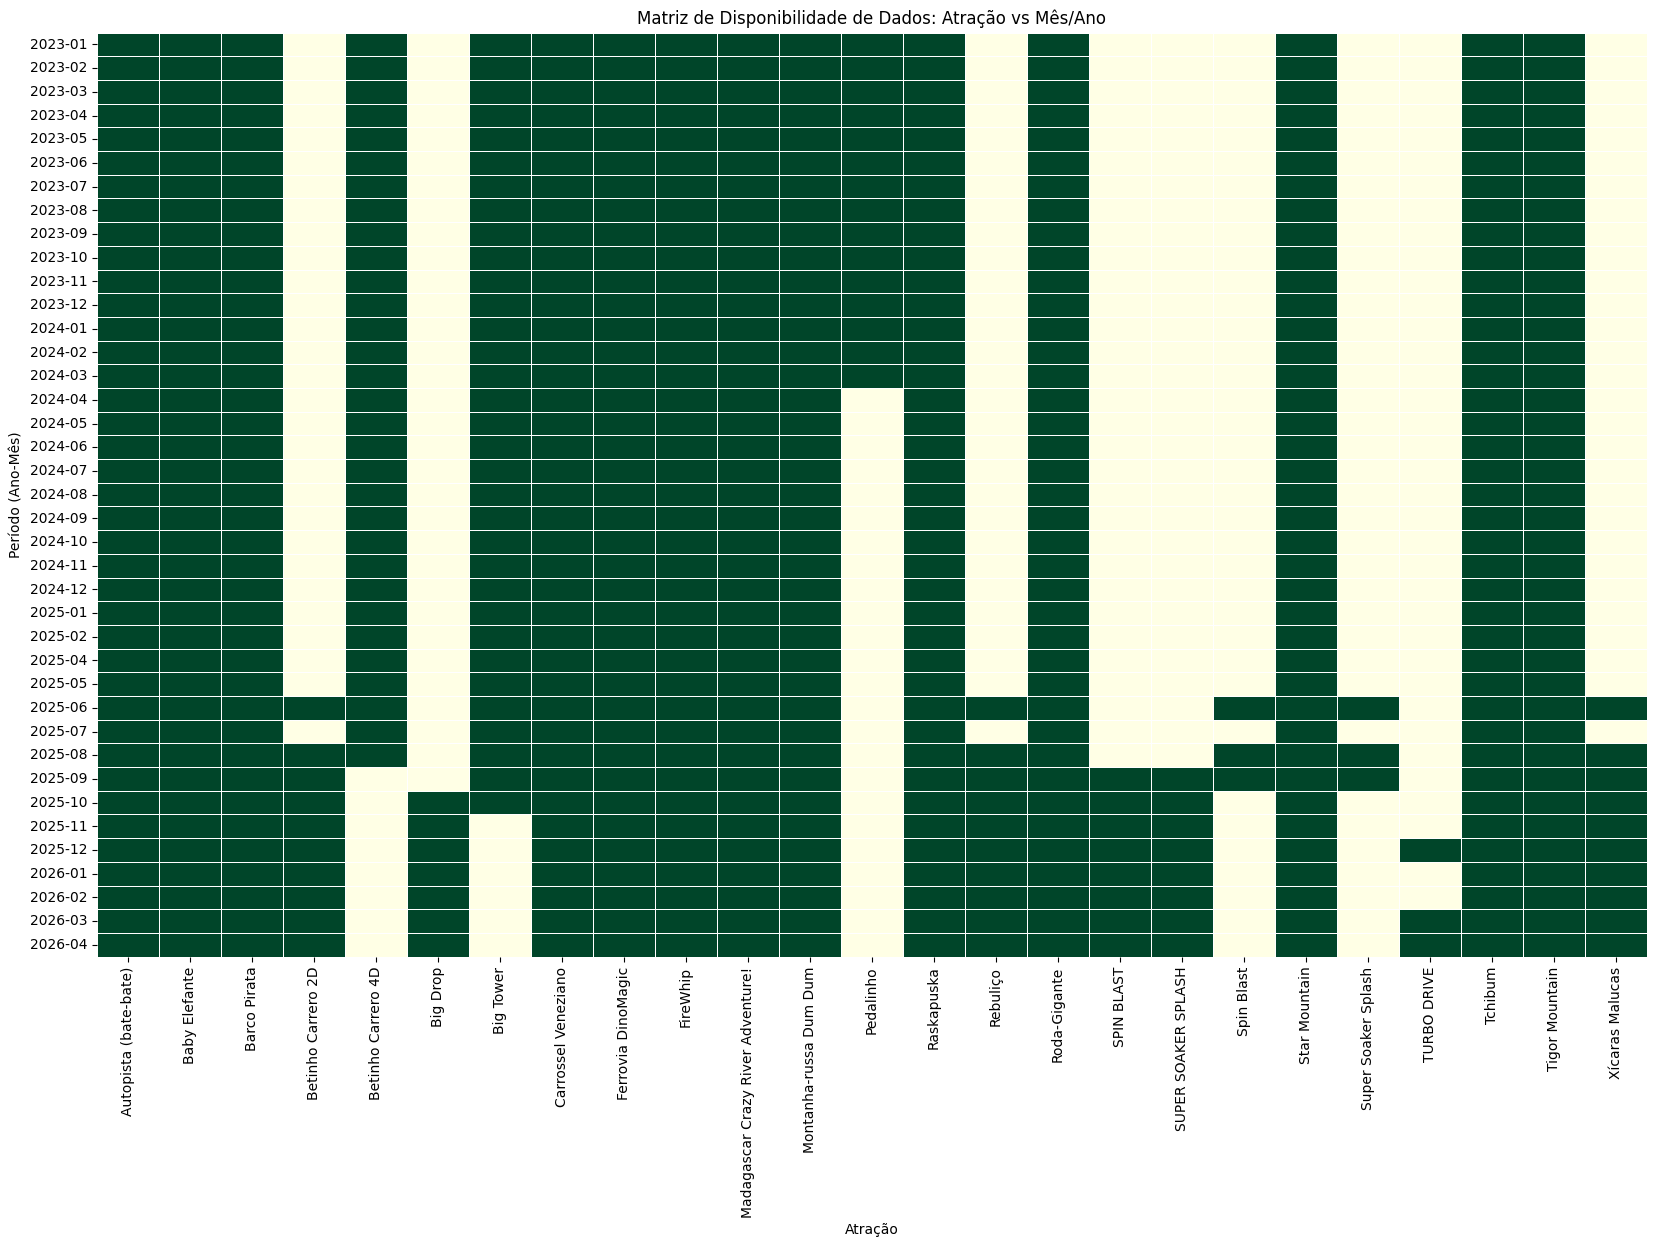

In [6]:
def auditoria_dados_mensais(df_input):
    # 1. Criar uma coluna combinada de Ano-Mês para as 40 linhas
    # Usamos o year_file e month_file que você criou no load_data
    df_audit = df_input.copy()
    df_audit['periodo'] = df_audit['year_file'].astype(str) + "-" + df_audit['month_file'].astype(str).str.zfill(2)
    
    # 2. Pivotar: Índices são os períodos, Colunas são os nomes das atrações
    # Vamos contar quantos registros existem para cada cruzamento
    matriz = df_audit.pivot_table(
        index='periodo', 
        columns='name', 
        values='wait_time', 
        aggfunc='count'
    )
    
    # 3. Transformar em presença (1 se tem dado, 0 se não tem)
    matriz_presenca = matriz.notnull().astype(int)
    
    return matriz_presenca

# Gerar a matriz
matriz_resumo = auditoria_dados_mensais(df)

# Exibir com um estilo visual para facilitar a detecção de buracos
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
sns.heatmap(matriz_resumo, cmap="YlGn", cbar=False, linewidths=.5)
plt.title("Matriz de Disponibilidade de Dados: Atração vs Mês/Ano")
plt.xlabel("Atração")
plt.ylabel("Período (Ano-Mês)")
plt.show()